In [ ]:
import vame


2026-06-20 00:00:56.657 INFO  --- [MainThread] numexpr.utils   : 164 : NumExpr defaulting to 8 threads.
2026-06-20 00:00:59.638 INFO  --- [MainThread] vame.util.auxiliary : 43 : Using CUDA — GPU: NVIDIA GeForce RTX 3090
2026-06-20 00:01:02.527 INFO  --- [MainThread] matplotlib.font_manager : 1847 : generated new fontManager
2026-06-20 00:01:02.817 INFO  --- [MainThread] vame.util.auxiliary : 43 : Using CUDA — GPU: NVIDIA GeForce RTX 3090
2026-06-20 00:01:04.409 | WARNING  | tqdm.autonotebook:<module>:28 - c:\Users\fbai_\anaconda3\envs\vame\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



AttributeError: module 'vame' has no attribute '__version__'

In [2]:
import numpy as np
import pandas as pd

# ── load your synthetic data ──────────────────────────────────
positions = np.load("rat_movement_large.npy")   # shape (T, 7, 2)
T, n_bodyparts, _ = positions.shape
print(f"Loaded: {positions.shape}")

bodyparts = [
    "head", "center", "tail",
    "right_front_paw", "left_front_paw",
    "right_back_paw", "left_back_paw",
]
scorer = "synthetic"

# ── build the 3-row DeepLabCut header ─────────────────────────
# columns are (bodypart, coord) pairs: x, y, likelihood for each
columns = pd.MultiIndex.from_product(
    [[scorer], bodyparts, ["x", "y", "likelihood"]],
    names=["scorer", "bodyparts", "coords"],
)

# ── fill the data array ───────────────────────────────────────
data = np.zeros((T, n_bodyparts * 3), dtype=np.float32)
for bi in range(n_bodyparts):
    data[:, bi * 3 + 0] = positions[:, bi, 0]   # x
    data[:, bi * 3 + 1] = positions[:, bi, 1]   # y
    data[:, bi * 3 + 2] = 1.0                    # likelihood (synthetic = perfect confidence)

df = pd.DataFrame(data, columns=columns)
df.index.name = None

# ── save ──────────────────────────────────────────────────────
out_path = "rat_movement_dlc.csv"
df.to_csv(out_path)
print(f"Saved DeepLabCut CSV: {out_path}")
print(f"Shape: {df.shape}  (should be {T} rows x {n_bodyparts*3} cols)")

Loaded: (88000, 7, 2)
Saved DeepLabCut CSV: rat_movement_dlc.csv
Shape: (88000, 21)  (should be 88000 rows x 21 cols)


In [3]:
import vame

config_file, config_data = vame.init_new_project(
    project_name="rat_vame",
    poses_estimations=["rat_movement_dlc.csv"],
    source_software="DeepLabCut",
    fps=30,
)

vame.preprocessing(
    config=config_data,
    centered_reference_keypoint="center",
    orientation_reference_keypoint="head",
)

vame.create_trainset(config=config_data)
vame.train_model(config=config_data)
vame.evaluate_model(config=config_data)

vame.segment_session(config=config_data)
vame.community(config=config_data, cut_tree=2)

2026-06-20 00:02:39.813 INFO  --- [MainThread] vame.initialize_project.new : 125 : Created "D:\_Dev\2026\vae_jackie\rat_vame\data"
2026-06-20 00:02:39.814 INFO  --- [MainThread] vame.initialize_project.new : 125 : Created "D:\_Dev\2026\vae_jackie\rat_vame\data\raw"
2026-06-20 00:02:39.831 INFO  --- [MainThread] vame.initialize_project.new : 125 : Created "D:\_Dev\2026\vae_jackie\rat_vame\data\processed"
2026-06-20 00:02:39.831 INFO  --- [MainThread] vame.initialize_project.new : 125 : Created "D:\_Dev\2026\vae_jackie\rat_vame\results"
2026-06-20 00:02:39.832 INFO  --- [MainThread] vame.initialize_project.new : 125 : Created "D:\_Dev\2026\vae_jackie\rat_vame\model"
2026-06-20 00:02:39.833 INFO  --- [MainThread] vame.initialize_project.new : 125 : Created "D:\_Dev\2026\vae_jackie\rat_vame\model\pretrained_model"
2026-06-20 00:02:39.834 INFO  --- [MainThread] vame.initialize_project.new : 125 : Created "D:\_Dev\2026\vae_jackie\rat_vame\model\evaluate"
2026-06-20 00:02:39.835 INFO  --- [Ma

Found candidate label files:
  15_hmm_label_rat_movement_dlc.npy                  shape=(87971,)
  motif_usage_rat_movement_dlc.npy                   shape=(15,)
  15_hmm_label_rat_movement_dlc.npy                  shape=(87971,)
  motif_usage_rat_movement_dlc.npy                   shape=(15,)
  cohort_community_label_rat_movement_dlc.npy        shape=(87971,)

Using: D:\_Dev\2026\vae_jackie\rat_vame\results\rat_movement_dlc\VAME\hmm-15\15_hmm_label_rat_movement_dlc.npy
Evaluating on 87,971 frames

ARI : 0.213
NMI : 0.464
Top-100 motifs cover 100.0% of frames
Purity : 0.761


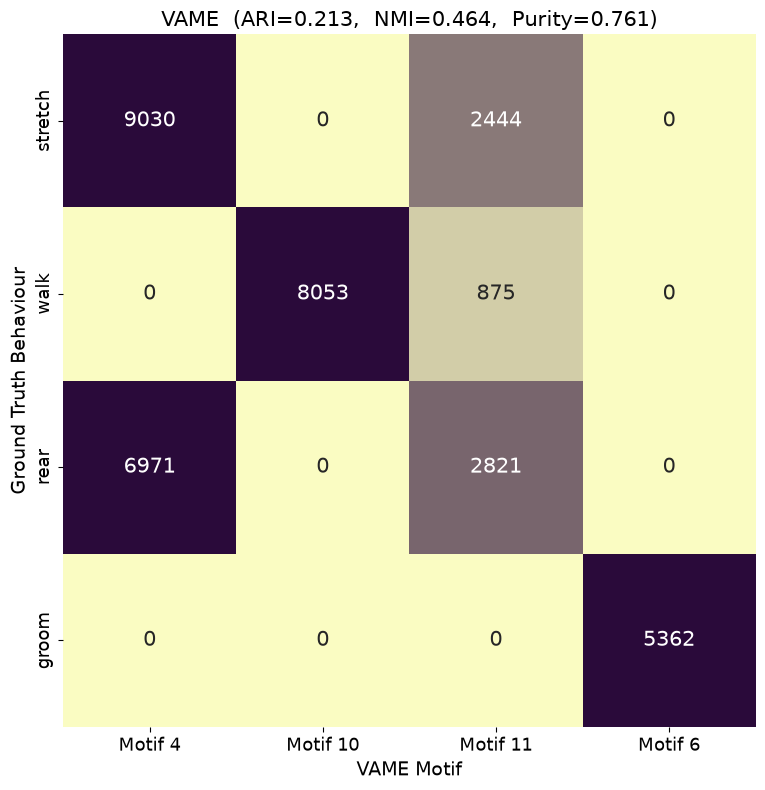

In [ ]:
# ── 5. full confusion matrix — ALL motifs, no top-N filter ─────
motif_ids    = np.unique(vame_motifs)
n_motifs     = len(motif_ids)
motif_to_col = {m: i for i, m in enumerate(motif_ids)}

cm = np.zeros((len(behaviour_names), n_motifs), dtype=int)
for gt, pred in zip(gt_trimmed, vame_motifs):
    cm[beh_to_idx[gt], motif_to_col[pred]] += 1

purity = np.sum(np.max(cm, axis=0)) / np.sum(cm)
print(f"Purity (all {n_motifs} motifs): {purity:.3f}")

# ── 6. column ordering for a readable diagonal band ────────────
# Hungarian picks one best motif per behaviour → diagonal anchors (top-left block)
row_ind, col_ind = linear_sum_assignment(-cm)
anchor_cols = list(col_ind[np.argsort(row_ind)])

# every remaining motif: grouped by its dominant behaviour, largest first
dominant_beh = np.argmax(cm, axis=0)
col_total    = cm.sum(axis=0)
remaining    = [c for c in range(n_motifs) if c not in set(anchor_cols)]
remaining    = sorted(remaining, key=lambda c: (dominant_beh[c], -col_total[c]))

col_order  = anchor_cols + remaining
cm_diag    = cm[:, col_order]
row_labels = behaviour_names
col_labels = [f'{motif_ids[c]}' for c in col_order]

# ── 7. plot (same style; auto-scales to motif count) ───────────
cmap   = LinearSegmentedColormap.from_list('custom', ["#fafcc2", "#2a0a3a"])
n_cols = cm_diag.shape[1]
annot  = n_cols <= 25            # annotations get unreadable past ~25 columns

fig, ax = plt.subplots(figsize=(max(9, n_cols * 0.5), 4.5))
sns.heatmap(cm_diag, annot=annot, fmt='d', ax=ax, cmap=cmap,
            xticklabels=col_labels, yticklabels=row_labels,
            vmin=0, vmax=np.max(cm_diag) * 0.5, cbar=True,
            annot_kws={"size": 9}, square=False,
            linewidths=0.5, linecolor='white')
ax.set_xlabel("VAME Motif", fontsize=14)
ax.set_ylabel("Ground Truth Behaviour", fontsize=14)
ax.set_title(f"VAME  (ARI={ari:.3f},  NMI={nmi:.3f},  Purity={purity:.3f})", fontsize=15)
ax.tick_params(axis='x', labelsize=10, rotation=90)
ax.tick_params(axis='y', labelsize=13)
plt.tight_layout()
plt.show()